# AIoT Project

In [26]:
import os

# basic data engineering
import pandas as pd
import numpy as np
import scipy

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# db
import pymongo
from bson import ObjectId

# configs & other
import yaml
from tqdm.notebook import tqdm_notebook
from datetime import datetime
from time import time

from psynlig import pca_explained_variance_bar

# utils processing
from utils import sliding_window_pd
from utils import apply_filter
from utils import filter_instances
from utils import flatten_instances_df
from utils import df_rebase
from utils import rename_df_column_values

# utils visualization
from utils_visual import plot_instance_time_domain
from utils_visual import plot_instance_3d
from utils_visual import plot_np_instance
from utils_visual import plot_heatmap
from utils_visual import plot_scatter_pca

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Start time of execution

In [2]:
time_start = time()

## Load configuration

In [3]:
config_path = os.path.join(os.getcwd(), "config.yml")

with open(config_path) as file:
    config = yaml.load(file, Loader=yaml.FullLoader)

In [4]:
client = pymongo.MongoClient(config["client"])

In [5]:
db = client[config["db"]]
coll = db[config["col"]]

In [6]:
found_keys = coll.distinct("_id")
print(f'Found {len(found_keys)} keys in the collection')

Found 25 keys in the collection


## Load data

In [7]:
# scroll up data
# results = list(coll.find({"gesture_id": "scroll-up-index"}, {"data": True, "gesture_id": True}))
results = list(coll.find({}, {"data": True, "gesture_id": True}))
print(f'Found {len(results)} keys in the collection')

Found 25 keys in the collection


In [ ]:
all_chunks = pd.DataFrame(results)
# print(len(all_chunks))

ids = all_chunks['gesture_id'].unique().tolist()
# print(ids)

gestures = []
for id in ids:
    gesture_chunks = all_chunks[all_chunks['gesture_id'] == id]
    current_data = gesture_chunks['data']
    
    chunks = []
    for chunk in current_data:
        # print(chunk)
        df = pd.DataFrame(chunk)
        dp = df.drop(df.tail(200).index, inplace=True)
        dp = df.drop(df.head(200).index, inplace=True)
        chunks.append((id, df))

    joined_gesture = pd.concat([df for _, df in chunks], ignore_index=True)
    gestures.append((id, joined_gesture))

    # print(len(chunks[0][1]))
    # print(chunks[0][1].head())

    # print(len(joined_gesture))
    # print(joined_gesture.head())
    
    
print(len(gestures))
print(gestures[0][1].head())


5
   acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z
0  0.000 -0.503  0.842  3.171  2.744  1.463
1  0.001 -0.505  0.844  3.780  3.659  1.829
2 -0.004 -0.511  0.842  5.305  3.902  2.317
3 -0.003 -0.510  0.838  6.646  3.841  3.293
4  0.001 -0.510  0.833  7.439  3.841  4.634


## Explore the nature of the data

In [9]:
dfs = gestures
for df in dfs:
    print(df[1].head())
# throw away acc to see whats up
# df = df.drop(columns=['gyr_x', 'gyr_y', 'gyr_z'])
# for df in dfs:
    # df[1].drop(columns=['acc_x', 'acc_y', 'acc_z'], inplace=True)
    # df[1].drop(columns=['gyr_x', 'gyr_y', 'gyr_z'], inplace=True)

   acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z
0  0.000 -0.503  0.842  3.171  2.744  1.463
1  0.001 -0.505  0.844  3.780  3.659  1.829
2 -0.004 -0.511  0.842  5.305  3.902  2.317
3 -0.003 -0.510  0.838  6.646  3.841  3.293
4  0.001 -0.510  0.833  7.439  3.841  4.634
   acc_x  acc_y  acc_z  gyr_x   gyr_y  gyr_z
0 -0.086 -0.269  0.960  0.122   2.317 -0.671
1 -0.093 -0.268  0.964  0.671   4.085 -1.768
2 -0.097 -0.268  0.962  1.707   6.585 -3.232
3 -0.089 -0.266  0.962  2.683   9.939 -5.122
4 -0.095 -0.268  0.958  3.963  12.866 -7.378
   acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z
0  0.712 -0.733  0.103 -1.280 -0.366 -0.183
1  0.708 -0.733  0.103 -1.159 -0.305 -0.122
2  0.707 -0.736  0.103 -0.915 -0.122 -0.122
3  0.709 -0.734  0.101 -0.793  0.122 -0.244
4  0.712 -0.732  0.103 -0.793  0.549 -0.366
   acc_x  acc_y  acc_z  gyr_x  gyr_y  gyr_z
0  0.516  0.222  0.847 -2.500  1.098 -0.427
1  0.516  0.222  0.851 -2.744  0.854 -0.427
2  0.511  0.226  0.842 -2.744  1.220 -0.488
3  0.519  0.224  0.843 -2.

             Gesture  Duration (s)
0  scroll-down-index        316.85
1    scroll-up-index        335.57
2     texting-single        315.20
3  swipe-right-index        319.22
4   swipe-left-index        329.29


<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



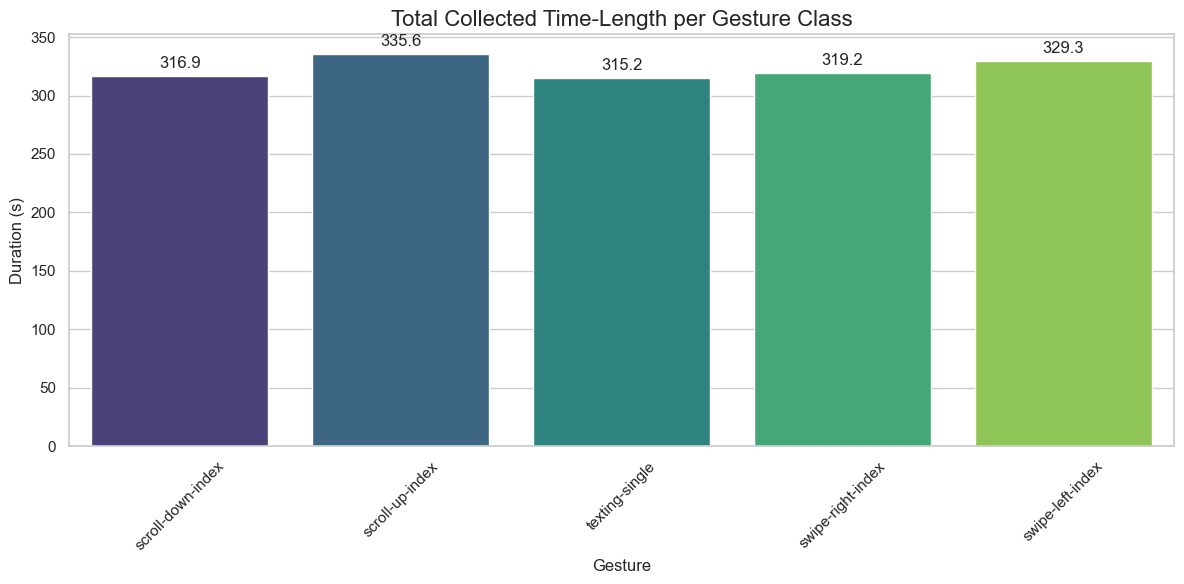

In [31]:
from utils_visual import plot_bar

sampling_rate = 100
durations = []
for gesture_id, df in gestures:
    total_samples = len(df)
    duration_seconds = total_samples / sampling_rate
    durations.append({'Gesture': gesture_id, 'Duration (s)':
        duration_seconds})

duration_df = pd.DataFrame(durations)
print(duration_df)
   
plot_bar(duration_df, title='Total Collected Time-Length per Gesture Class')

## Data Processing

FOCUSING ON  scroll-down-index
Number of filtered instances in the list: 30


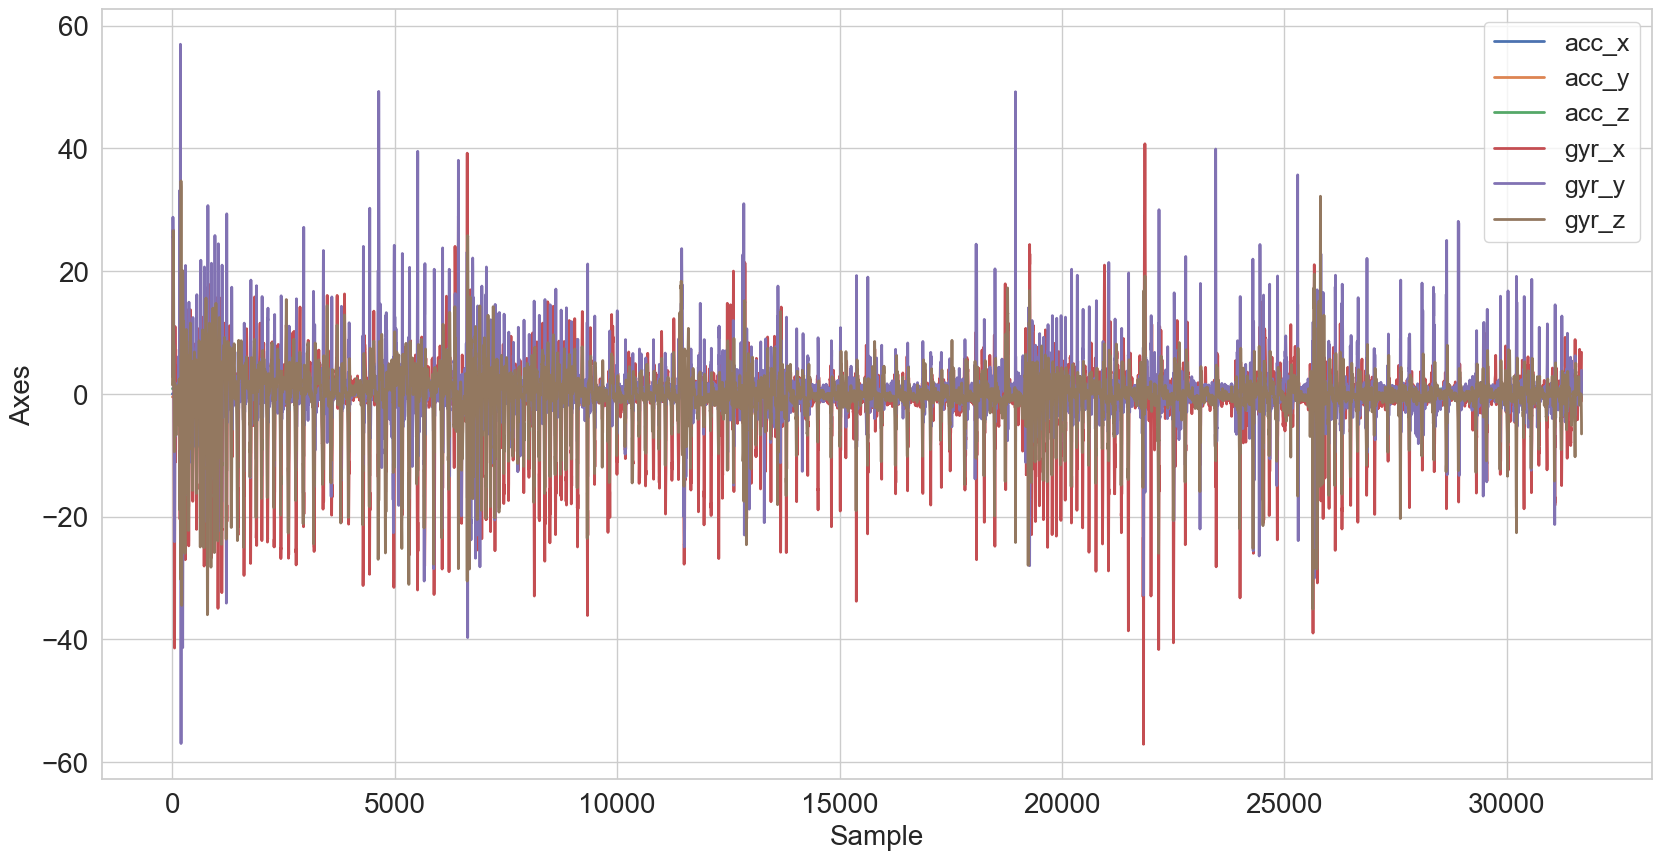

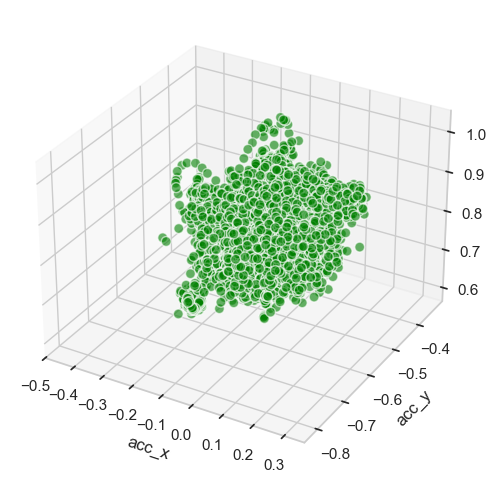

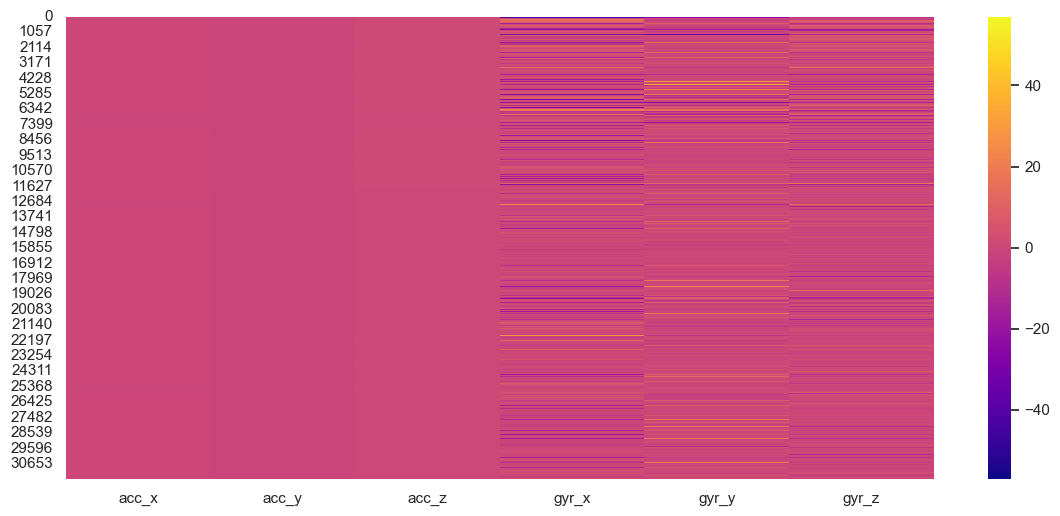

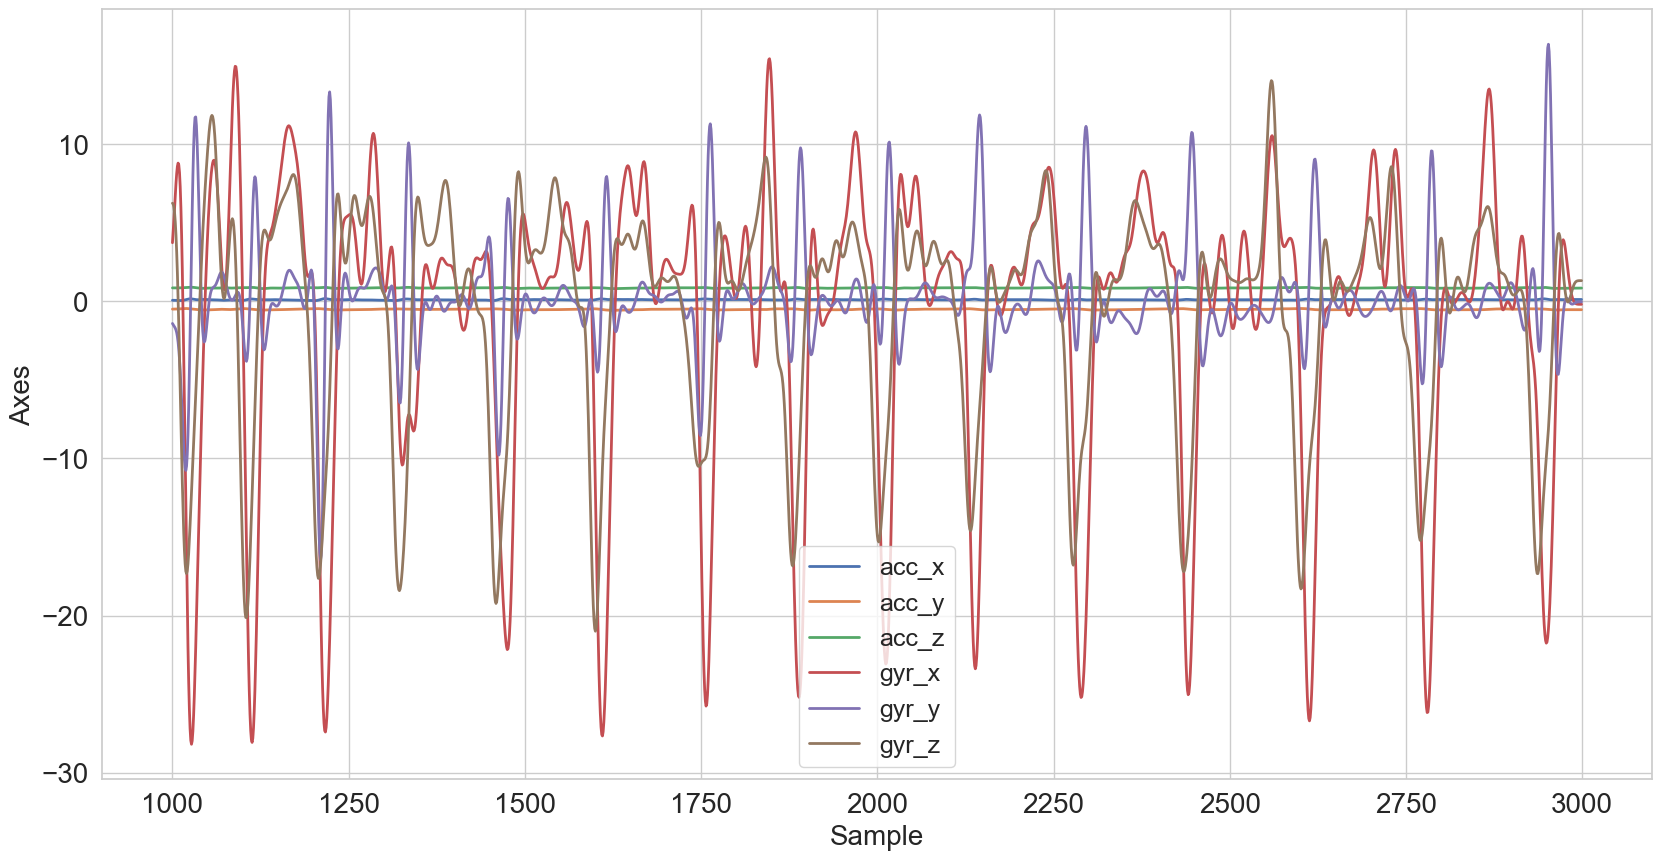

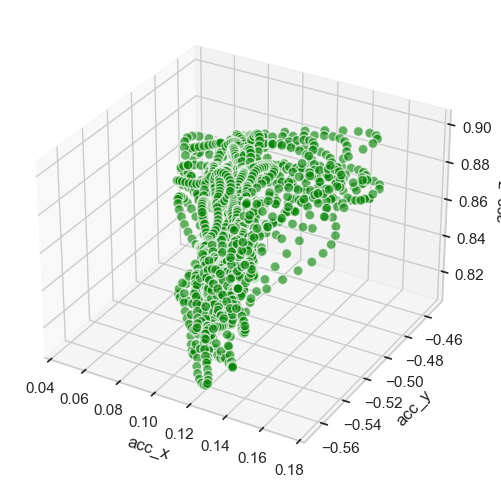

In [ ]:
# df = dfs[0]
# print('FOCUSING ON ', df[0])
# data = df[1]
# plot_instance_time_domain(data)
# # plot_instance_3d(data, axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(data, axes_list=['acc_x', 'acc_y', 'acc_z'])
# plot_heatmap(data)

# # slice data into windows
# clips = sliding_window_pd(data, ws=2000, overlap=1000, print_stats=False)
# total_clips = len(clips)
# print(f'Total clips: {total_clips}')
# fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
# plot_instance_time_domain(fclips[1])
# # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
# plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])


Number of filtered instances in the list: 30
GESTURE_ID: scroll-down-index
Number of filtered instances in the list: 32
GESTURE_ID: scroll-up-index
Number of filtered instances in the list: 30
GESTURE_ID: texting-single
Number of filtered instances in the list: 30
GESTURE_ID: swipe-right-index
Number of filtered instances in the list: 31
GESTURE_ID: swipe-left-index


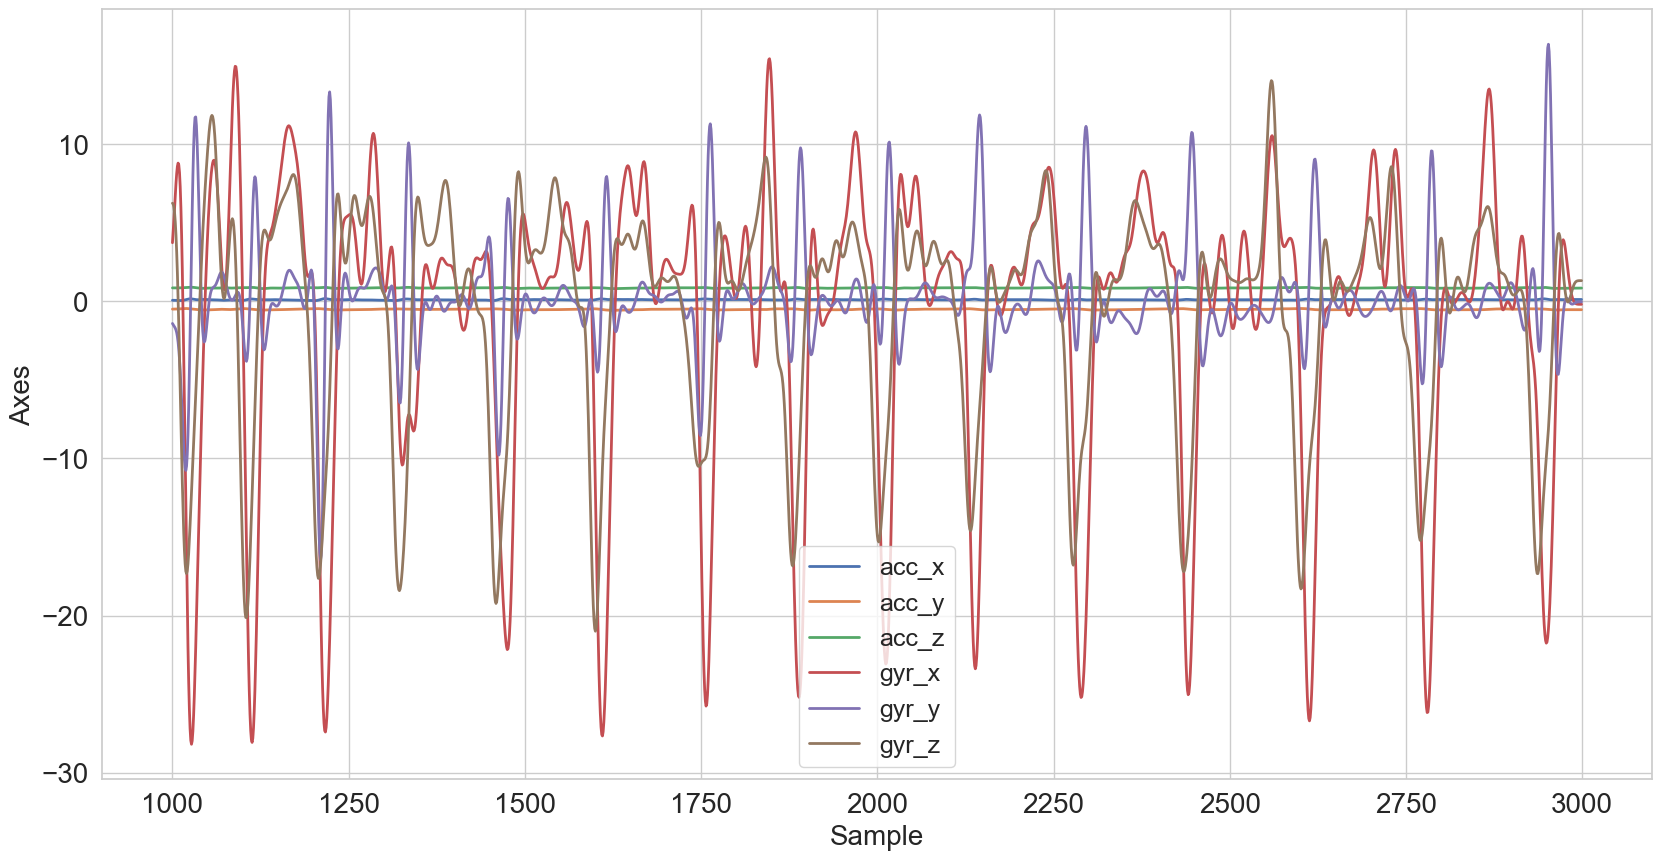

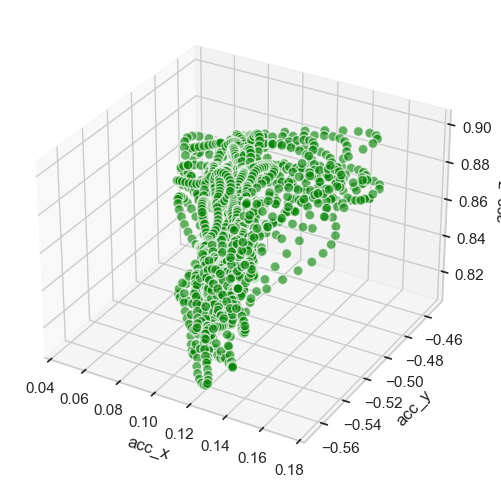

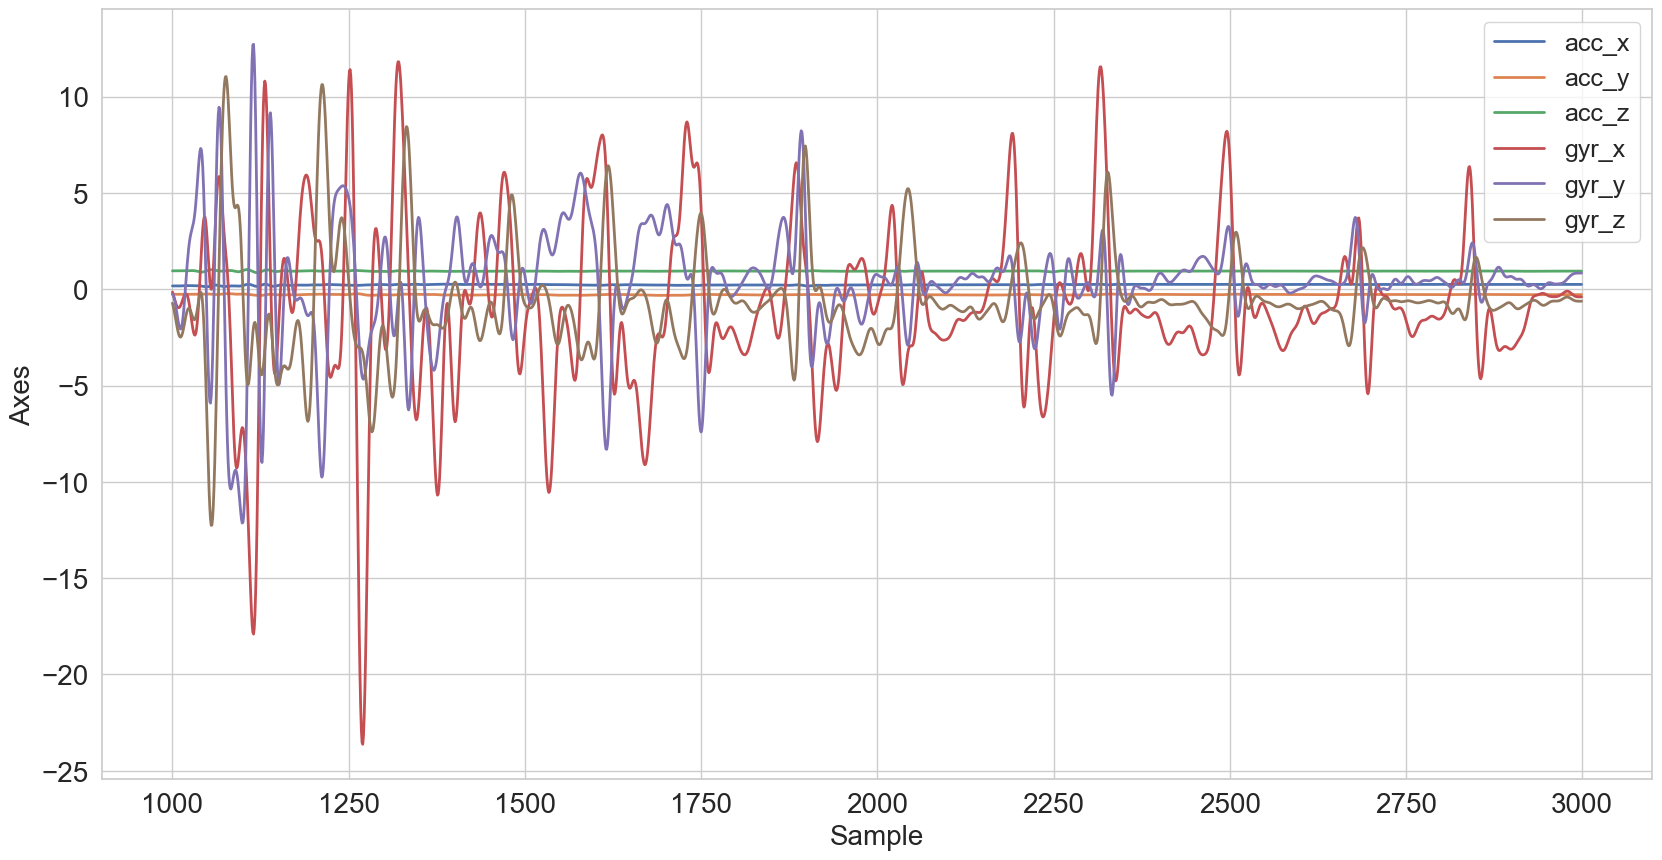

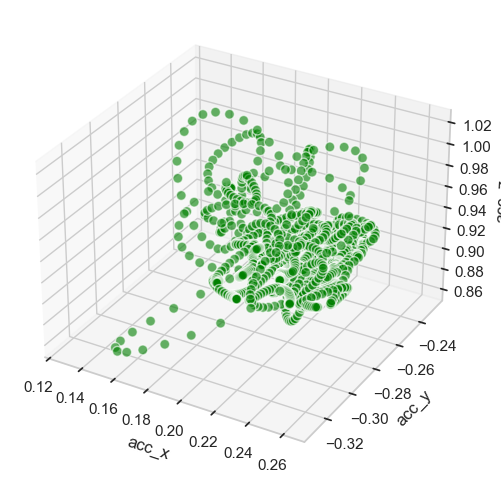

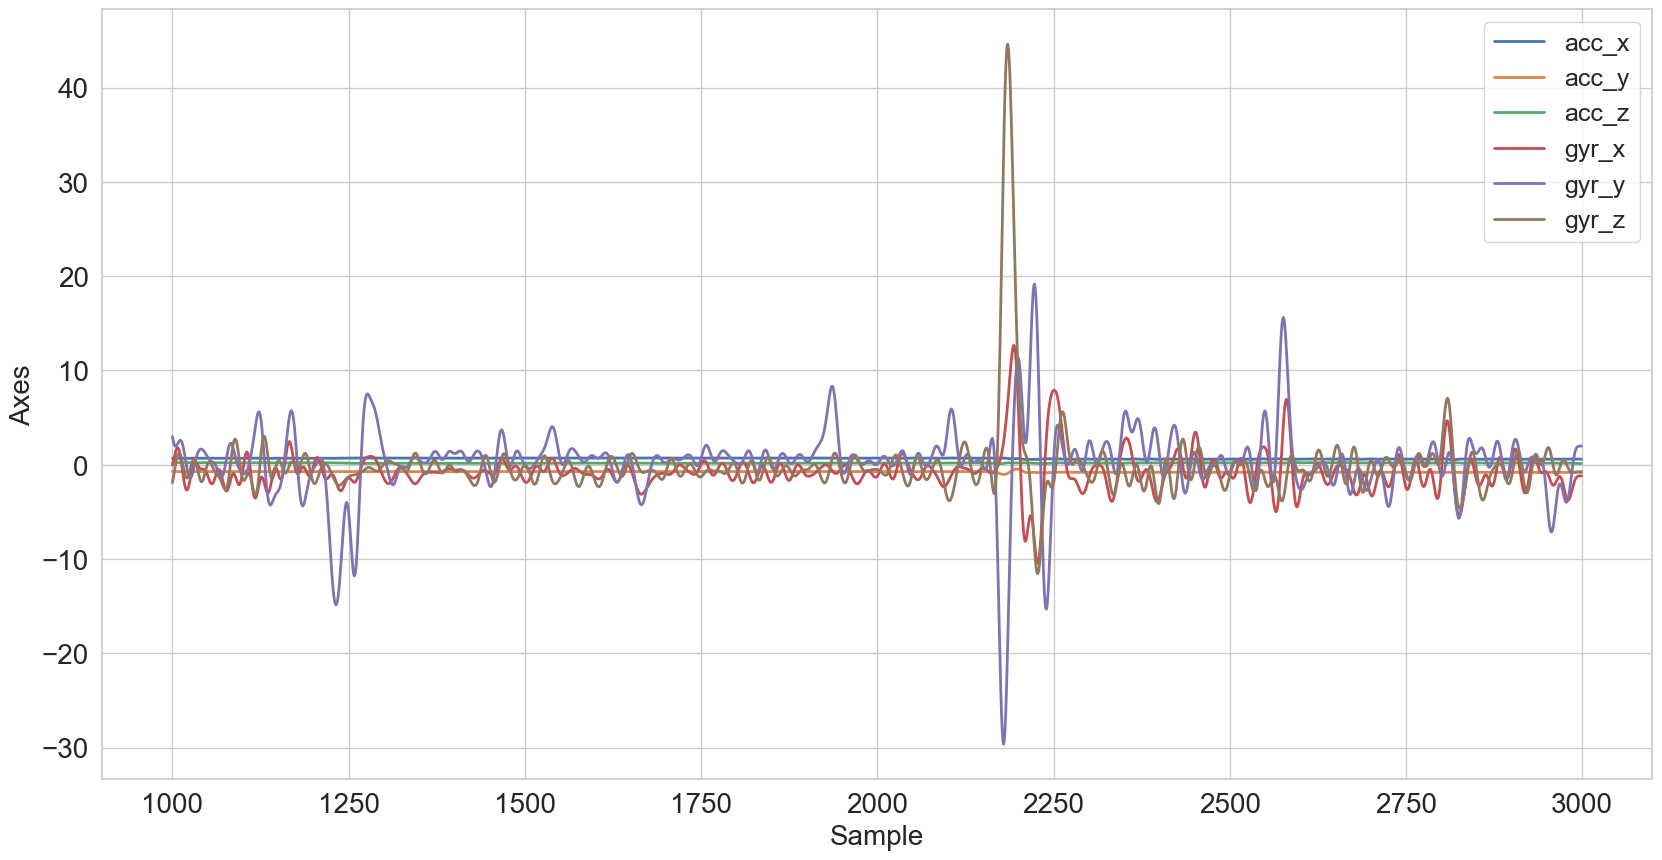

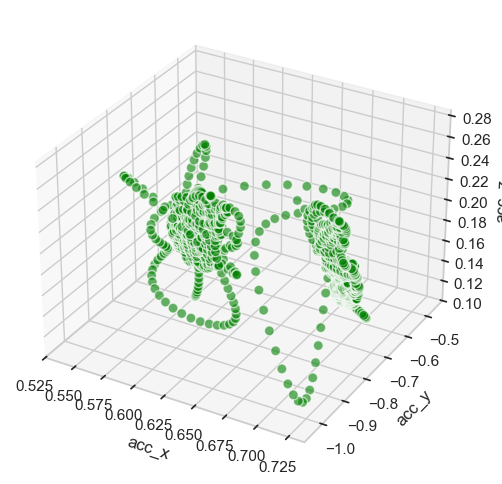

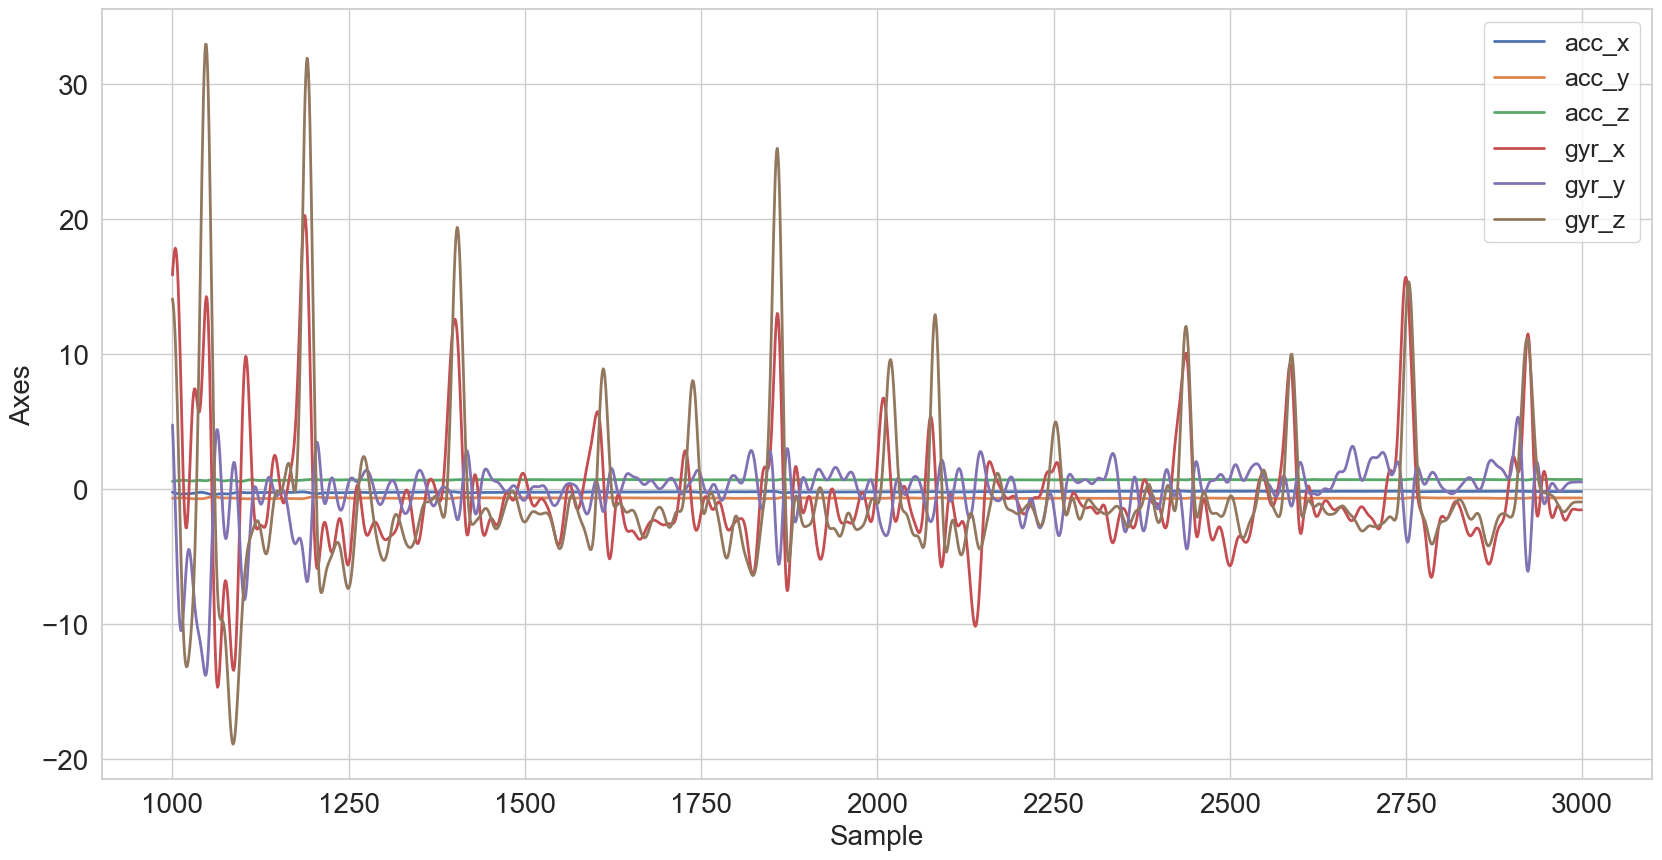

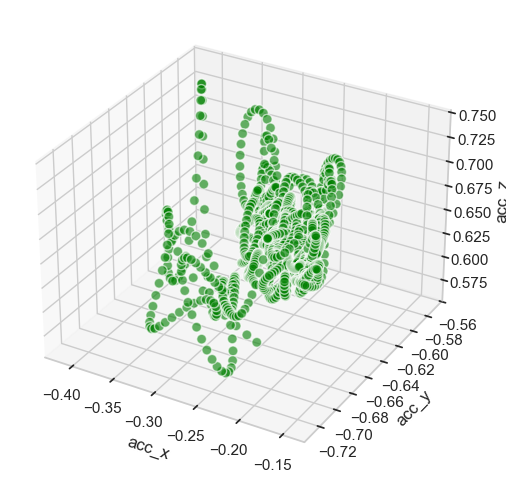

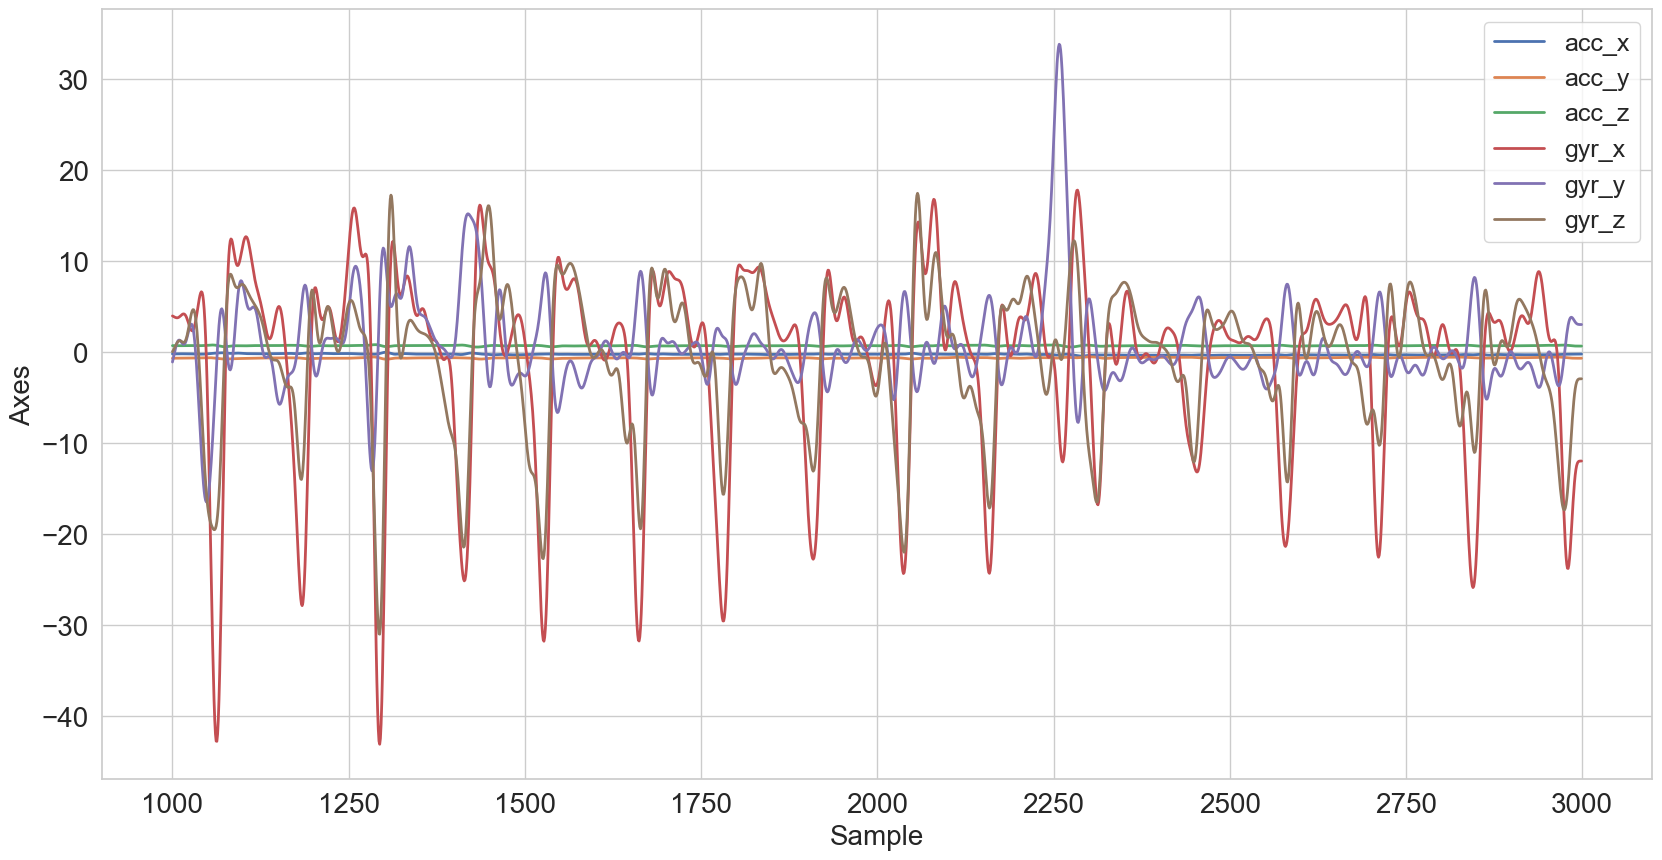

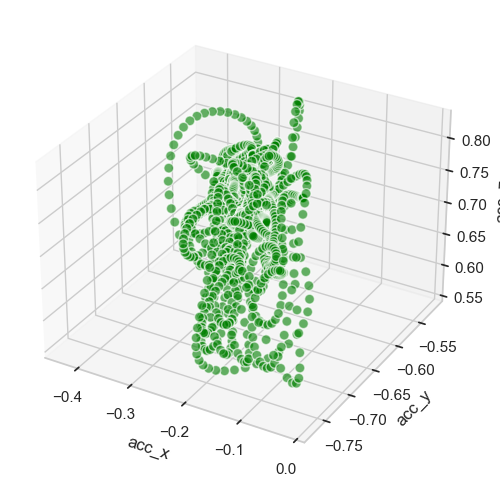

In [ ]:
clips_arr = []
for id, data in dfs:
    # slice data into windows
    clips = sliding_window_pd(data, ws=2000, overlap=1000, print_stats=False)
    total_clips = len(clips)
    # print(f'Total clips: {total_clips}')
    clips_arr.append({'Gesture': id, 'Total Clips': total_clips})
    fclips = filter_instances(clips, order=5, wn=0.1, filter_type='lowpass')
    print(f'GESTURE_ID: {id}')
    plot_instance_time_domain(fclips[1])
    # plot_instance_3d(fclips[1], axes_list=['gyr_x', 'gyr_y', 'gyr_z'])
    plot_instance_3d(fclips[1], axes_list=['acc_x', 'acc_y', 'acc_z'])


             Gesture  Total Clips
0  scroll-down-index           30
1    scroll-up-index           32
2     texting-single           30
3  swipe-right-index           30
4   swipe-left-index           31


<string>:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



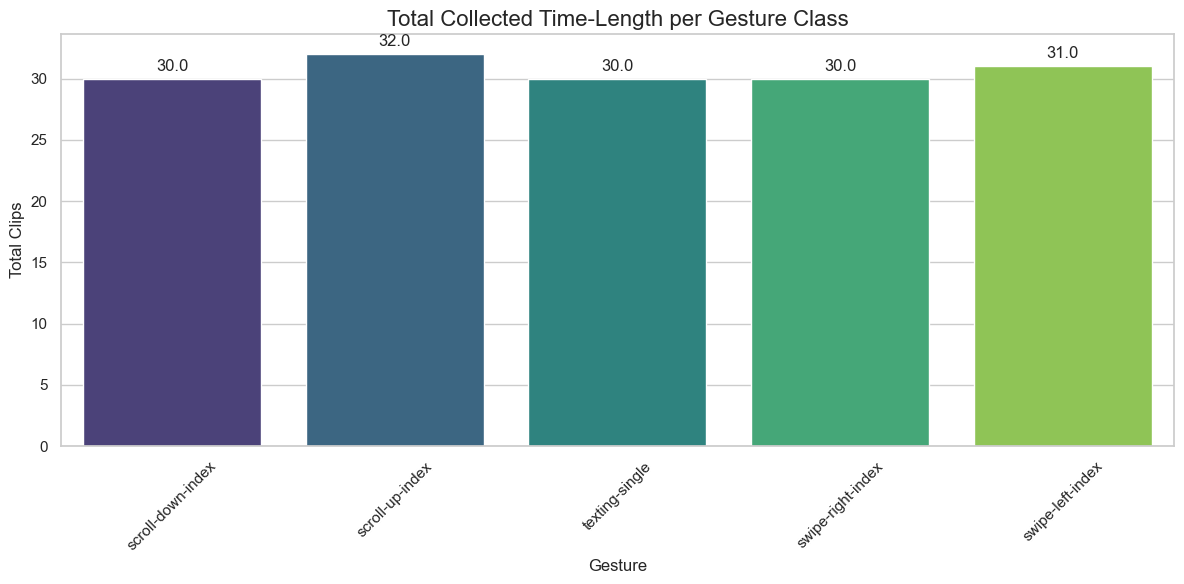

In [ ]:
# 2. Convert to a DataFrame for easier plotting
clips_df = pd.DataFrame(clips_arr)
print(clips_df)
   
plot_bar(clips_df, title='Total Clips per Gesture Class')

## Train/Test split

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, shuffle=True, random_state=42)

## Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

## Classifier - Statistical Learning

### Apply simple classifier

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

### Evaluate simple classifier

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [ ]:
from sklearn.metrics import classification_report

### Apply optimization with Grid Search and/or Cross-validation

In [ ]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

### Evaluate optimized classifier